In [1]:
import time
import matplotlib.pyplot as plt

from motion_planning.lightning import Lightning
from motion_planning.space import PointRobot
from motion_planning.obstacle_sets import BiasedPassage
from motion_planning.database import generate_database

from motion_planning.circle_approximation import ApproximationSpace

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Setup Base Robot & Environment

In [22]:
env = PointRobot()
env.set_obstacles(BiasedPassage(bias=0.5, num_walls=3))

# Generate Path Database

In [ ]:
db_save_path = '../saves/lightning_example_database.pickle'
db = generate_database(db_save_path)
lightning = Lightning(env, db_save_path)

# Create Task to Solve

In [20]:
start, target = env.space.sample_task()

# Compute Path for Guidance for Given Task

In [24]:
start_time = time.time()
path = lightning.search(start, target)
end_time = time.time()
print(f"Time to search: {end_time - start_time}", len(path))

Time to compute Candidate Paths: 25.873033046722412
Search Time: 1.3286640644073486, Collision Checks: 337332
Search Time: 0.15140318870544434, Collision Checks: 337726
Time to repair path: 1.4833099842071533
Lightning Total Search Time: 27.35648512840271
Time to search: 27.356691360473633 104


# Draw Search Tree

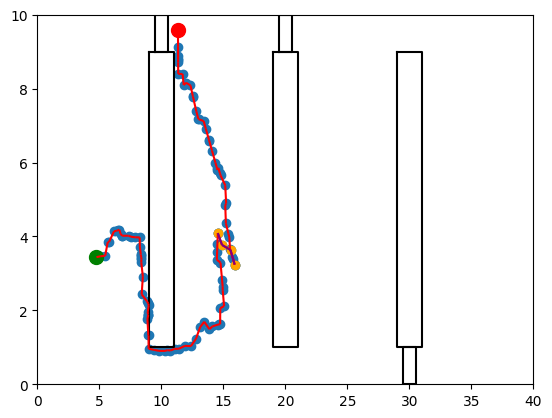

In [27]:
lightning.draw(plt.gca(), path, show_unrepaired_path=True, verbose=True)
plt.show()